# Прогноз пролонгации страхового договора

## Цель проекта
Построить модель бинарной классификации для прогнозирования пролонгации страхового договора и предсказать `target` для строк, где `target = -1`.

## Постановка задачи
В датасете содержатся данные по страховым договорам на автомобили. Целевая переменная:\
`1` — договор будет пролонгирован\
`0` — договор не будет пролонгирован \
`-1` — значение неизвестно, его необходимо предсказать

## Какая бизнес-задача решается
По сути решается задача **удержания клиента**.  
Модель помогает заранее оценить вероятность пролонгации и разделить клиентов на соответствующие группы.

На практике такой скоринг можно использовать, например, для:
- приоритизации звонков и коммуникаций
- таргетирования 
- распределения ограниченного бюджета на удержание
- сегментации клиентской базы по вероятности пролонгации

## Pipeline проекта
1. подготовка и аудит данных
2. train / validation / test
3. feature engineering
4. baseline-модели
5. подбор параметров для Random Forest
6. обучение CatBoost с early stopping
7. выбор лучшей модели по validation
8. подбор порога на validation
9. финальная оценка на test
10. переобучение финальной модели на всей размеченной части и предсказание `target = -1`

## По какой метрике выбирается модель
Здесь важна не только общая способность модели разделять классы, но и качество работы именно по классу пролонгации (`target = 1`).

Поэтому:
- **основная метрика выбора модели — PR-AUC на validation**, она лучше отражает качество модели на положительном классе и полезна, когда классы несбалансированы
- **ROC-AUC** используется как дополнительная метрика ранжирования
- **Brier score** показывает качество вероятностей
- **F1** используется уже на этапе выбора threshold, когда нужно перевести вероятности в решение 0/1


In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_STATE = 42
DATA_PATH = "test.csv"

## Загрузка данных
Сначала загрузим данные и разделим их на:
- `размеченную часть`: строки, где target уже известен
- `часть для скоринга`: строки, где target = -1

In [2]:
df = pd.read_csv(DATA_PATH)

train_df = df[df["target"] != -1].copy()
score_df = df[df["target"] == -1].copy()

print("Общий размер датасета:", df.shape)
print("Размеченная часть:", train_df.shape)
print("Часть для скоринга:", score_df.shape)

display(df.head())

Общий размер датасета: (10863, 30)
Размеченная часть: (7598, 30)
Часть для скоринга: (3265, 30)


,ID,Filial,Type_ts,passport_region,VIP,Brand,Model,Yr_production,GAP,married,...,Age,Exp,discount,Amount - gr,sex,premium_car,price_gr,price_prc,OSAGO_clnt,target
0,1,Магнитогорский,Иностранные,Челябинская область,NaN,TOYOTA,RAV 4,2018,Нет,Состоит в браке,...,42,24,1.00,1400000,M,0,55000,0.040,0,0
1,2,Магнитогорский,Отечественные,Челябинская область,NaN,LADA,GRANTA,2016,Нет,Состоит в браке,...,41,4,1.05,200000,M,0,10000,0.010,0,0
2,3,Ростовский,Отечественные,Ростовская область,NaN,LADA,GRANTA,2018,Нет,Не состоит в браке,...,49,20,0.95,400000,F,0,30000,0.065,1,1
3,4,Казанский,Иностранные,Республика Татарстан,NaN,KIA,RIO,2016,Нет,Не состоит в браке,...,40,15,1.10,400000,M,0,10000,0.020,1,0
4,5,Московский,Иностранные,Москва,NaN,DATSUN,ON-DO,2018,Нет,Состоит в браке,...,58,23,1.00,400000,M,0,10000,0.015,0,0


## Первичный аудит данных

Проверим:
- типы признаков
- количество пропусков
- число уникальных значений
- наличие полных дубликатов

In [3]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_cnt": df.isna().sum(),
    "missing_rate": df.isna().mean().round(4),
    "nunique": df.nunique(dropna=True),
}).sort_values(["missing_rate", "nunique"], ascending=[False, False])

display(audit)
print("Количество полных дубликатов:", df.duplicated().sum())

,dtype,missing_cnt,missing_rate,nunique
VIP,object,10579,0.9739,2
ID,int64,0,0.0000,10863
Model,object,0,0.0000,200
passport_region,object,0,0.0000,85
Age,int64,0,0.0000,67
Exp,int64,0,0.0000,57
Brand,object,0,0.0000,23
Filial,object,0,0.0000,22
price_prc,float64,0,0.0000,21
Amount - gr,int64,0,0.0000,16


Количество полных дубликатов: 0


В данных присутствуют как числовые, так и категориальные признаки. Существенная часть признаков связана с характеристиками клиента, автомобиля, параметрами договора и стоимостью страхования.

На этапе аудита важно было проверить пропуски, дубликаты и типы данных, так как ошибки в этих частях напрямую влияют на стабильность всего пайплайна. Критических проблем, делающих данные непригодными для моделирования, не выявлено.

## Анализ целевой переменной
Проверим баланс классов в размеченной части.

In [4]:
target_dist = train_df["target"].value_counts(normalize=True).sort_index()

display(target_dist.rename("Распределение target").to_frame())

,Распределение target
target,
0,0.687813
1,0.312187


Распределение целевой переменной не является полностью сбалансированным, поэтому при сравнении моделей важно смотреть не только на ROC-AUC, но и на PR-AUC, F1 и качество вероятностных оценок.

Задача не сводится только к бинарной классификации. Важно не просто отделить один класс от другого, но и получить устойчивые вероятности пролонгации, которые можно использовать для ранжирования клиентов и последующих бизнес-решений.

## Разделение на train / validation / test
Используем понятную схему:
- `train` — обучение моделей;
- `validation` — сравнение моделей и подбор порога;
- `test` — финальная честная проверка выбранной модели.

In [5]:
train_full_df, test_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["target"],
    random_state=RANDOM_STATE
)

train_df_split, valid_df = train_test_split(
    train_full_df,
    test_size=0.25,   # 0.25 * 0.8 = 0.2 от всей размеченной выборки(в итоге 60/20/20)
    stratify=train_full_df["target"],
    random_state=RANDOM_STATE
)

print("train:", train_df_split.shape)
print("validation:", valid_df.shape)
print("test:", test_df.shape)

print("Target rate train:", round(train_df_split["target"].mean(), 4))
print("Target rate validation:", round(valid_df["target"].mean(), 4))
print("Target rate test:", round(test_df["target"].mean(), 4))

train: (4558, 30)
validation: (1520, 30)
test: (1520, 30)
Target rate train: 0.3122
Target rate validation: 0.3118
Target rate test: 0.3125


Разбиение выполнено корректно: размеры выборок выглядят разумно, а доли положительного класса в train, validation и test практически равны.  
Это значит, что validation можно использовать для выбора модели, а test — как честную финальную проверку.

## Feature Engineering

Добавим несколько интерпретируемых признаков.

Какие и зачем:
- `car_age` — возраст автомобиля. Я заменяю год выпуска на возраст автомобиля, так как это более интерпретируемая величина и напрямую связана с вероятностью пролонгации.
- `exp_ratio` — отношение стажа к возрасту клиента отражает уровень водительского опыта.
- `age_minus_exp` — разница между возрастом и стажем, позволяет оценить возраст начала водительского стажа.
- `kbm_flag` — индикатор ухудшения коэффициента `KBM`. Я перевожу изменение KBM в бинарный индикатор ухудшения, чтобы явно выделить негативный страховой сигнал.
- `VIP_missing_flag` — индикатор отсутствия значения в признаке `VIP`. Я не удаляю признак, а добавляю индикатор пропуска, так как отсутствие значения само по себе может нести информацию о клиенте.

In [6]:
def add_features(df):
    df = df.copy()

    # Текущий год берём динамически
    year = pd.Timestamp.today().year
    
    # Возраст автомобиля
    if "Yr_production" in df.columns:
        df["car_age"] = year - df["Yr_production"]

    # Характеристики опыта вождения
    if {"Age", "Exp"}.issubset(df.columns):
        df["exp_ratio"] = df["Exp"] / (df["Age"] + 1)
        df["age_minus_exp"] = df["Age"] - df["Exp"]

    # Индикатор ухудшения KBM
    if "delta_kbm" in df.columns:
        df["kbm_flag"] = (df["delta_kbm"] > 0).astype(int)

    # Индикатор пропуска по VIP
    if "VIP" in df.columns:
        df["VIP_missing_flag"] = df["VIP"].isna().astype(int)

    return df

In [7]:
train_fe = add_features(train_df_split)
valid_fe = add_features(valid_df)
test_fe = add_features(test_df)
score_fe = add_features(score_df)

# Удаляем исходный дублирующий признак
for frame in [train_fe, valid_fe, test_fe, score_fe]:
    if "Yr_production" in frame.columns:
        del frame["Yr_production"]

print("train_fe:", train_fe.shape)
print("valid_fe:", valid_fe.shape)
print("test_fe:", test_fe.shape)
print("score_fe:", score_fe.shape)

train_fe: (4558, 34)
valid_fe: (1520, 34)
test_fe: (1520, 34)
score_fe: (3265, 34)


После feature engineering появились дополнительные интерпретируемые признаки, отражающие характеристики автомобиля, клиента и страховой истории.  
Признак `Yr_production` был удалён в пользу `car_age`, так как возраст автомобиля содержит ту же информацию, но интерпретируется заметно проще.

## EDA: числовые признаки

Далее проанализируем ключевые числовые признаки, которые потенциально могут быть связаны с вероятностью пролонгации договора.

Я целенаправленно выбираю наиболее содержательные признаки, а не вывожу все числовые столбцы подряд.

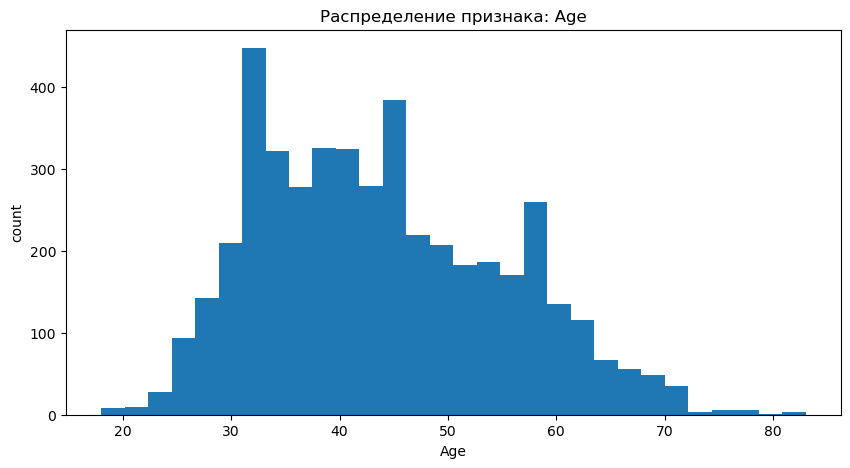

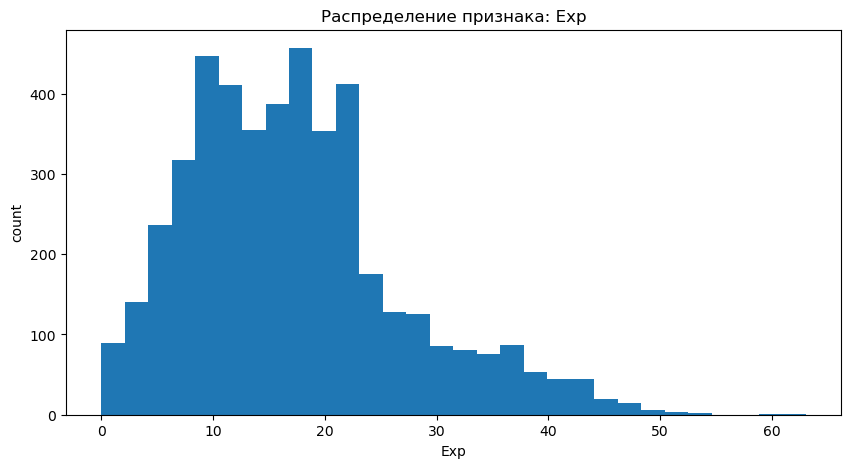

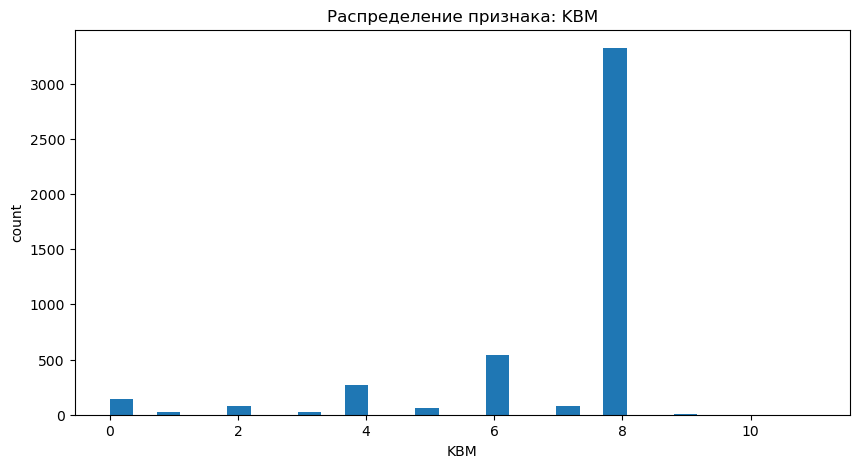

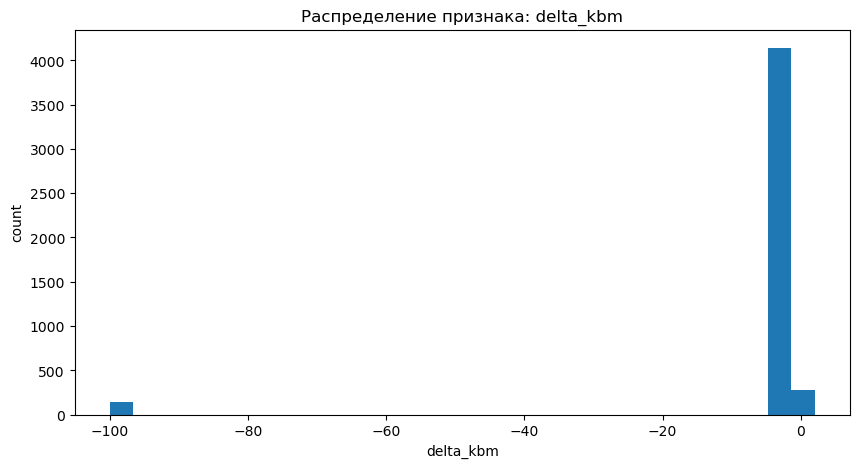

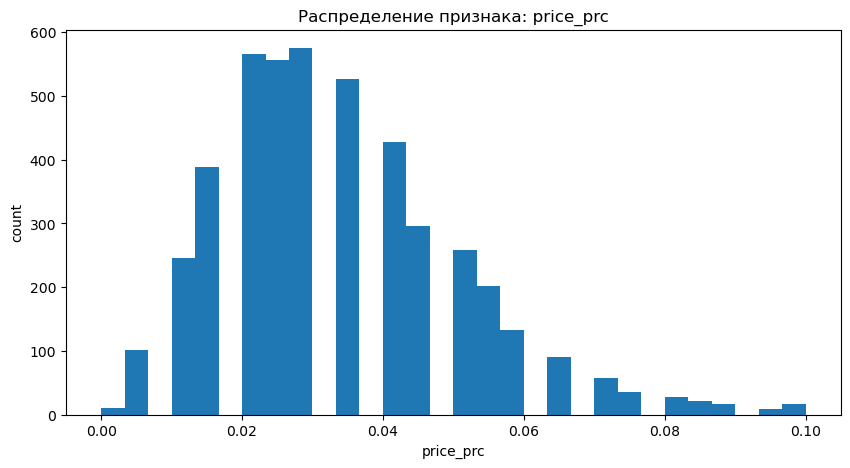

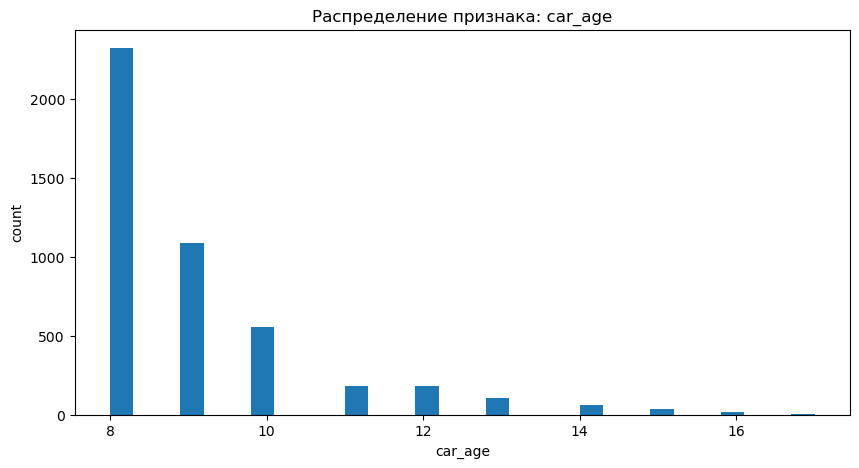

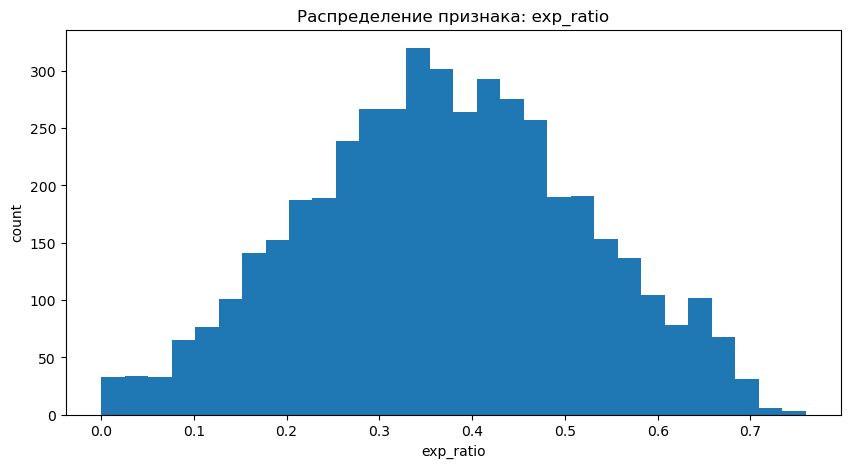

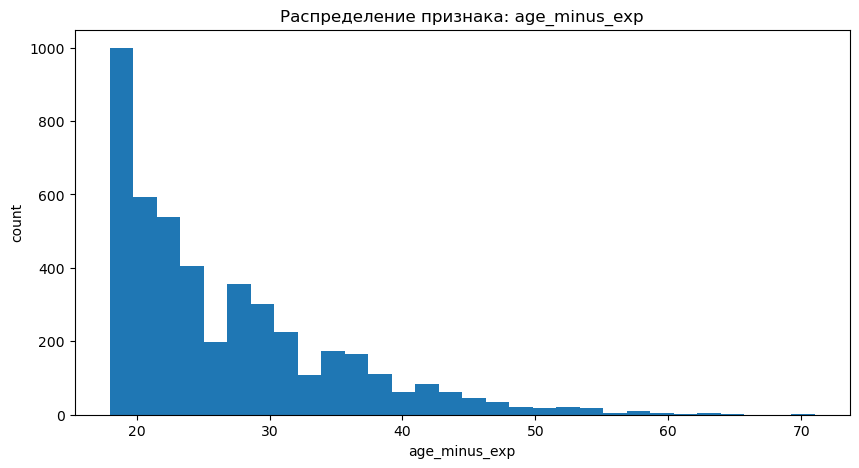

In [8]:
num_cols_preview = [
    c for c in ["Age", "Exp", "KBM", "delta_kbm", "price_prc", "car_age", "exp_ratio", "age_minus_exp"]
    if c in train_fe.columns
]

for col in num_cols_preview:
    plt.figure()
    plt.hist(train_fe[col].dropna(), bins=30)
    plt.title(f"Распределение признака: {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

По распределениям числовых признаков видно, что данные неоднородны: часть признаков имеет достаточно "аккуратно" распределены, а часть имеет длинные хвосты и потенциальные выбросы.  
Особенно важно, что признаки, связанные с характеристиками клиента и автомобиля (`Age`, `Exp`, `car_age`), выглядят содержательно и могут нести полезный сигнал для модели. Также видно, что страховые и ценовые признаки (`KBM`, `delta_kbm`, `price_prc`) распределены неравномерно, что делает их потенциально информативными для прогноза пролонгации.

По графикам видно, что возраст клиентов и стаж вождения сосредоточены в реалистичных диапазонах, без явных аномалий. Распределение `price_prc` более скошено и имеет длинный хвост, что может указывать на наличие отдельных сегментов по стоимости договора. Признак `car_age` выглядит содержательно: возраст автомобиля распределён неравномерно, а значит, может влиять на вероятность пролонгации.

## EDA: категориальные признаки

Для категориальных признаков важно смотреть не только частоты, но и среднюю долю пролонгации внутри каждой категории.

Это помогает понять, какие сегменты клиентов, каналы и продукты могут быть связаны с target.

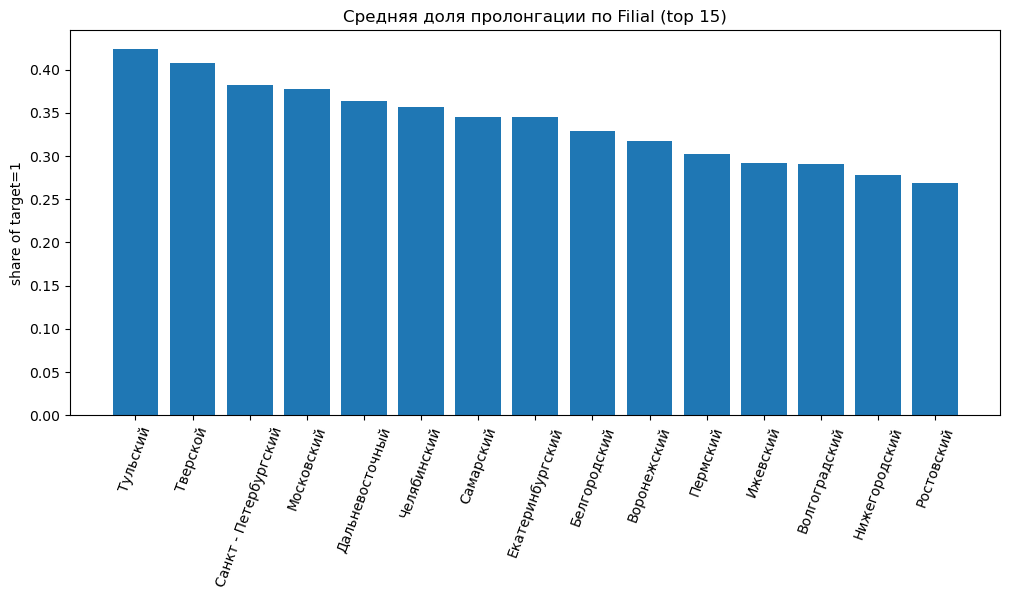

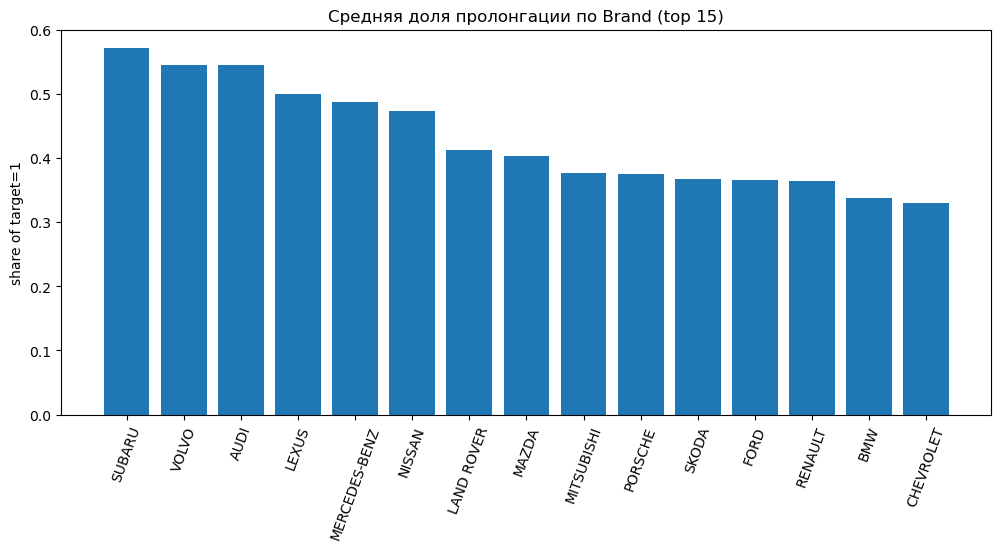

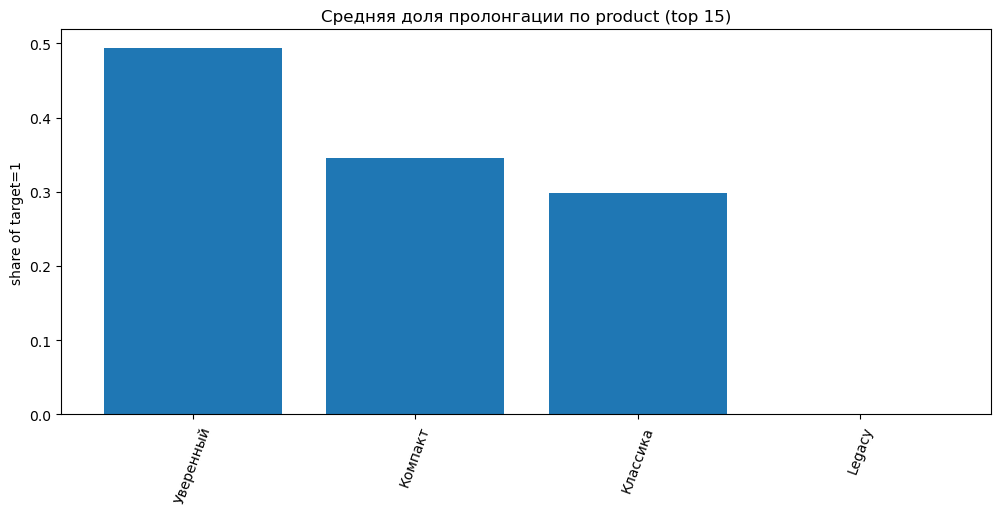

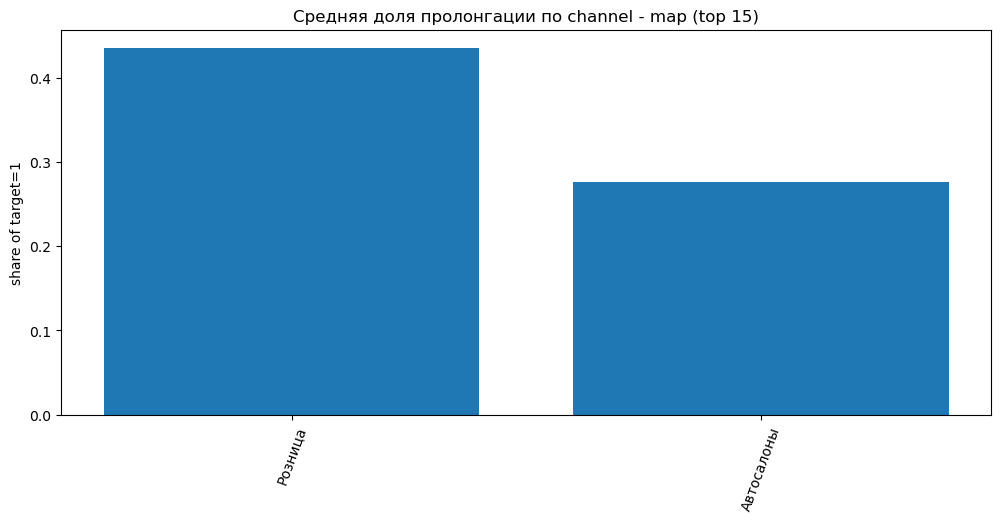

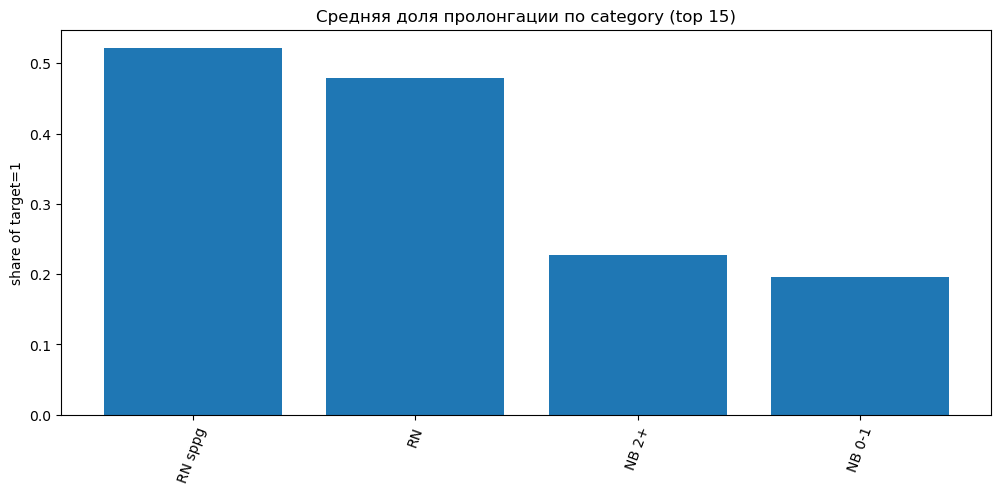

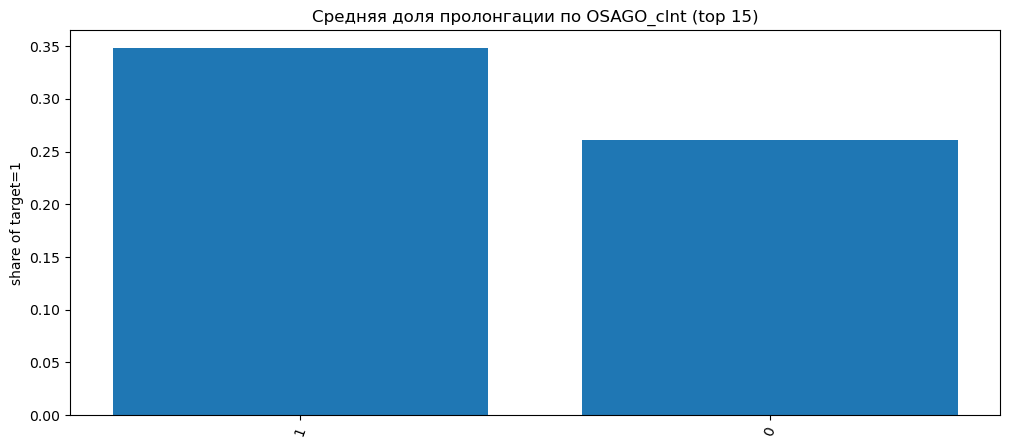

In [9]:
cat_cols_preview = [
    c for c in ["Filial", "Brand", "product", "channel - map", "category", "OSAGO_clnt"]
    if c in train_fe.columns
]

for col in cat_cols_preview:
    tmp = train_fe.groupby(col)["target"].mean().sort_values(ascending=False).head(15)

    plt.figure(figsize=(12, 5))
    plt.bar(tmp.index.astype(str), tmp.values)
    plt.title(f"Средняя доля пролонгации по {col} (top 15)")
    plt.xticks(rotation=70)
    plt.ylabel("share of target=1")
    plt.show()

По категориальным признакам видно, что доля пролонгации заметно различается между сегментами.  
Это особенно заметно для таких признаков, как канал продаж, продукт, филиал и клиентский сегмент. Значит, категориальные признаки, действительно, содержат полезный сигнал, и модель, умеющая качественно работать с ними, должна иметь преимущество.

Графики показывают, что средняя доля пролонгации неодинакова по различным категориям. Это означает, что признаки `Filial`, `Brand`, `product`, `channel - map`, `category` и `OSAGO_clnt` потенциально важны для прогноза. Особенно ценно, что различия наблюдаются не только между отдельными редкими категориями, но и между крупными сегментами, то есть сигнал выглядит устойчивым, а не случайным.

## Сравнение train и score

Перед моделированием полезно проверить, насколько часть с `target = -1` похожа на размеченную часть.

In [10]:
compare_missing = pd.DataFrame({
    "train_missing_rate": train_fe.isna().mean(),
    "score_missing_rate": score_fe.isna().mean(),
}).sort_values("train_missing_rate", ascending=False)

display(compare_missing.head(15))

,train_missing_rate,score_missing_rate
VIP,0.969724,0.976723
ID,0.000000,0.000000
price_prc,0.000000,0.000000
Exp,0.000000,0.000000
discount,0.000000,0.000000
Amount - gr,0.000000,0.000000
sex,0.000000,0.000000
premium_car,0.000000,0.000000
price_gr,0.000000,0.000000
OSAGO_clnt,0.000000,0.000000


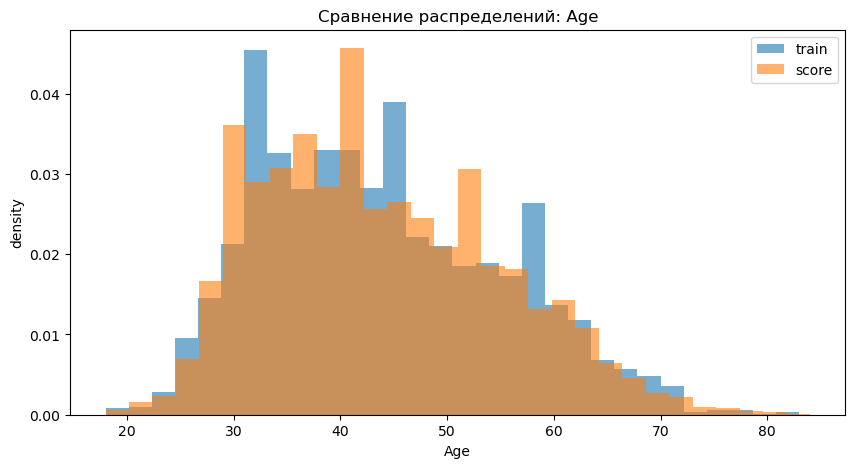

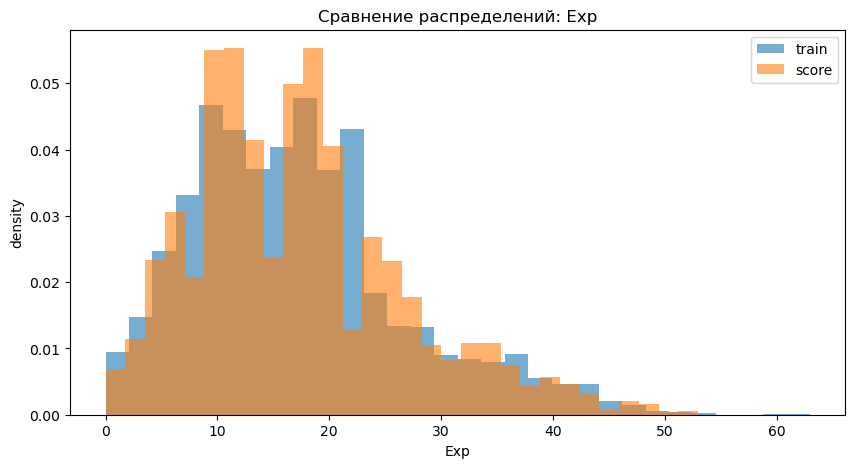

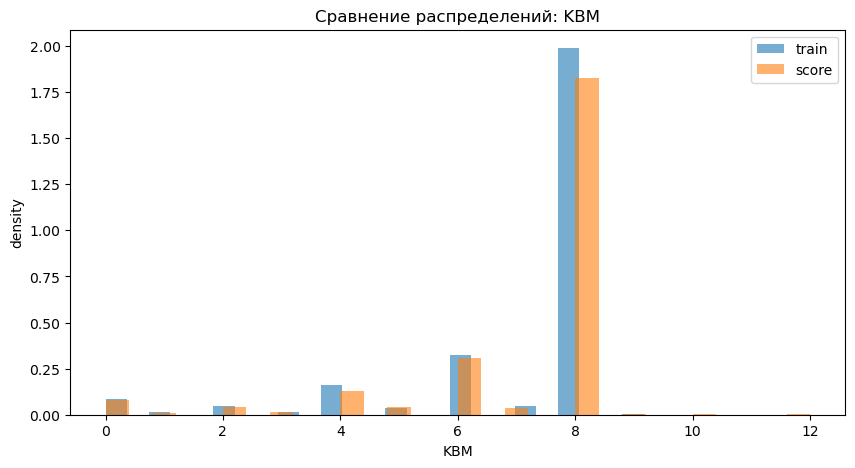

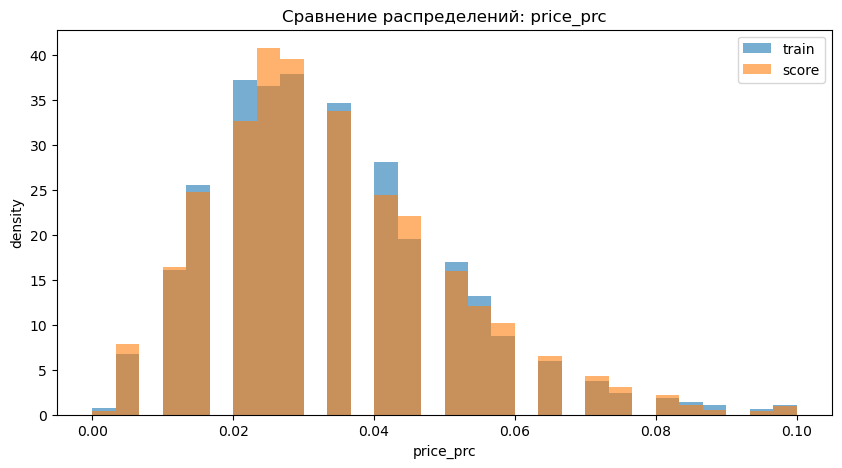

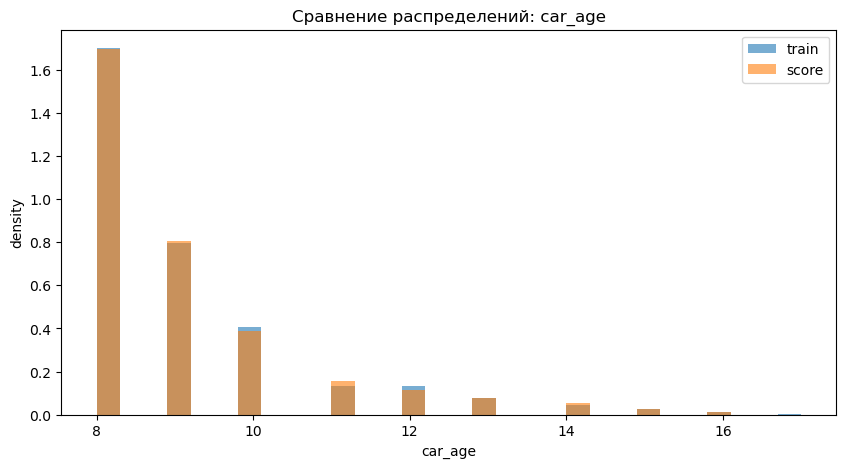

In [11]:
compare_num_cols = [c for c in ["Age", "Exp", "KBM", "price_prc", "car_age"] if c in train_fe.columns and c in score_fe.columns]

for col in compare_num_cols:
    plt.figure()
    plt.hist(train_fe[col].dropna(), bins=30, alpha=0.6, label="train", density=True)
    plt.hist(score_fe[col].dropna(), bins=30, alpha=0.6, label="score", density=True)
    plt.title(f"Сравнение распределений: {col}")
    plt.xlabel(col)
    plt.ylabel("density")
    plt.legend()
    plt.show()

Различия между train и score умеренные, это хорошо: модель будет применяться к данным, которые близки к тем, на которых она обучалась.

## Анализ корреляций и кандидаты на удаление признаков
Проверим:
- нет ли константных признаков
- нет ли сильно коррелированных числовых переменных

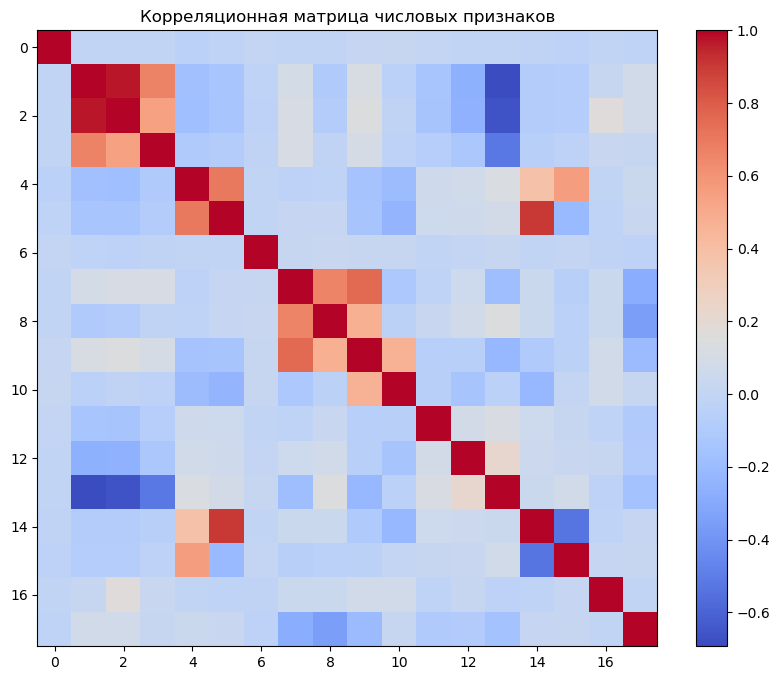

In [12]:
corr = train_fe.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.title("Корреляционная матрица числовых признаков")
plt.show()


Среди числовых признаков могут наблюдаться умеренные корреляции, что естественно для связанных характеристик клиента и автомобиля. Константные признаки, если они есть, будут исключены.

In [13]:
corr_matrix_abs = train_fe.corr(numeric_only=True).abs()

upper = corr_matrix_abs.where(
    np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool)
)

high_corr = [col for col in upper.columns if any(upper[col] > 0.75)]
high_corr

['KBM_prol_est', 'price_gr', 'exp_ratio']

При пороге 0.75 наблюдается высокая корреляция между признаками:
KBM_prol_est, exp_ratio и price_gr.

Однако данные признаки отражают разные аспекты:
- exp_ratio — опыт водителя
- price_gr — Сгруппированный тариф (руб.)
- KBM_prol_est — Прогноз КБМ (пролонгация)

Корреляция объясняется причинно-следственными связями, а не дублированием информации.

Я считаю, что признак KBM_prol_est необходимо исключить из модели, так как может содержать встроенную бизнес-логику или модельную оценку, что создаёт риск утечки информации.

Признаки exp_ratio и price_gr сохраняются, так как они отражают различные стороны поведения клиента и важны для интерпретации модели.

## Подготовка матрицы признаков

Сформируем:
- `X` — матрица признаков для обучения
- `y` — целевая переменная
- `X_score` — данные для финального скоринга
  
Исключаем:
- `target`
- константные признаки(не найдены)
- признаки с очень высокой корреляцией, если они найдены

In [15]:
drop_cols = ["target"]+ ['KBM_prol_est']

X_train = train_fe.drop(columns=drop_cols, errors="ignore")
y_train = train_fe["target"].astype(int)

X_valid = valid_fe.drop(columns=drop_cols, errors="ignore")
y_valid = valid_fe["target"].astype(int)

X_test = test_fe.drop(columns=drop_cols, errors="ignore")
y_test = test_fe["target"].astype(int)

X_score = score_fe.drop(columns=drop_cols, errors="ignore")

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test:", X_test.shape)
print("X_score:", X_score.shape)

X_train: (4558, 32)
X_valid: (1520, 32)
X_test: (1520, 32)
X_score: (3265, 32)


## Функции оценки качества и подбора порога
Порог выбирается не фиксированно как 0.5, а подбирается по validation.

In [16]:
def evaluate(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return {
        "ROC-AUC": roc_auc_score(y_true, proba),
        "PR-AUC": average_precision_score(y_true, proba),
        "F1": f1_score(y_true, pred),
        "Precision": precision_score(y_true, pred),
        "Recall": recall_score(y_true, pred),
        "Brier": brier_score_loss(y_true, proba),
    }

def find_best_threshold(y_true, proba, metric="f1"):
    thresholds = np.linspace(0.05, 0.95, 181)
    best_t = 0.5
    best_score = -1

    for t in thresholds:
        pred = (proba >= t).astype(int)
        if metric == "f1":
            score = f1_score(y_true, pred)
        elif metric == "precision":
            score = precision_score(y_true, pred)
        elif metric == "recall":
            score = recall_score(y_true, pred)
        else:
            raise ValueError("Unsupported metric")

        if score > best_score:
            best_score = score
            best_t = t

    return best_t, best_score

## Подготовка preprocessing для моделей

In [17]:
# Определяем типы признаков
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = [col for col in X_train.columns if col not in cat_cols + ["ID"]]

X_train_base = X_train.drop(columns=["ID"], errors="ignore").copy()
X_valid_base = X_valid.drop(columns=["ID"], errors="ignore").copy()
X_test_base = X_test.drop(columns=["ID"], errors="ignore").copy()

# работа с категориальными признаками(приводим к строкам и делаем OneHotEncoding)
for col in cat_cols:
    if col in X_train_base.columns:
        X_train_base[col] = X_train_base[col].astype(str)
        X_valid_base[col] = X_valid_base[col].astype(str)
        X_test_base[col] = X_test_base[col].astype(str)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            [col for col in num_cols if col in X_train_base.columns]
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            [col for col in cat_cols if col in X_train_base.columns]
        ),
    ]
)

## Сравнение baseline-моделей на validation

## DummyClassifier
Необходим, чобы убедиться, что более сложные алгоритмы работают лучше случайного классификатора и применение методов мл действительно обосновано.

In [18]:
dummy = Pipeline([
    ("prep", preprocessor),
    ("model", DummyClassifier(strategy="prior"))
])

dummy.fit(X_train_base, y_train)
dummy_valid_proba = dummy.predict_proba(X_valid_base)[:, 1]
dummy_valid_metrics = evaluate(y_valid, dummy_valid_proba)

pd.DataFrame([dummy_valid_metrics], index=["DummyClassifier"])

,ROC-AUC,PR-AUC,F1,Precision,Recall,Brier
DummyClassifier,0.5,0.311842,0.0,0.0,0.0,0.214597


### Вывод

DummyClassifier ожидаемо показывает слабое качество и задаёт нижнюю границу для задачи.  
Это подтверждает, что без использования информации из признаков задача не решается.

## Logistic Regression

In [19]:
logreg = Pipeline([
    ("prep", preprocessor), # Обработка числовых и категориальных признаков
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced")) # тк есть небольшой дисбаланс, балансируем классы
])

logreg.fit(X_train_base, y_train)
logreg_valid_proba = logreg.predict_proba(X_valid_base)[:, 1]
logreg_valid_metrics = evaluate(y_valid, logreg_valid_proba)

pd.DataFrame([logreg_valid_metrics], index=["LogisticRegression"])

,ROC-AUC,PR-AUC,F1,Precision,Recall,Brier
LogisticRegression,0.730629,0.532779,0.555653,0.475262,0.668776,0.211014


### Вывод

Логистическая регрессия уже даёт заметный прирост относительно DummyClassifier, значит, применение МЛ-моделей имеет смысл.

## Random Forest 

In [20]:
rf_results = []

# перебор гиперпараметров
for max_depth in [5, 10, 15]:
    for min_samples_leaf in [3, 5, 10]:
        rf = Pipeline([
            ("prep", preprocessor),
            ("model", RandomForestClassifier(
                n_estimators=200,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])

        rf.fit(X_train_base, y_train)
        valid_proba = rf.predict_proba(X_valid_base)[:, 1]

        rf_results.append({
            "max_depth": max_depth,
            "min_samples_leaf": min_samples_leaf,
            "ROC-AUC": roc_auc_score(y_valid, valid_proba),
            "PR-AUC": average_precision_score(y_valid, valid_proba),
        })

rf_tuning = pd.DataFrame(rf_results).sort_values("PR-AUC", ascending=False)
rf_tuning.head(10)

,max_depth,min_samples_leaf,ROC-AUC,PR-AUC
6,15,3,0.747047,0.563745
7,15,5,0.744621,0.561225
5,10,10,0.736898,0.560425
8,15,10,0.738163,0.560310
4,10,5,0.736977,0.557759
3,10,3,0.740892,0.556174
0,5,3,0.727310,0.546612
1,5,5,0.726878,0.544100
2,5,10,0.726223,0.540302


In [21]:
best_rf_params = rf_tuning.iloc[0]
best_rf_depth = int(best_rf_params["max_depth"])
best_rf_leaf = int(best_rf_params["min_samples_leaf"])

#создаем финальную модель с лучшими параметрами
rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=best_rf_depth,
        min_samples_leaf=best_rf_leaf,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf.fit(X_train_base, y_train)
rf_valid_proba = rf.predict_proba(X_valid_base)[:, 1]
rf_valid_metrics = evaluate(y_valid, rf_valid_proba)

pd.DataFrame([rf_valid_metrics], index=["RandomForest"])

,ROC-AUC,PR-AUC,F1,Precision,Recall,Brier
RandomForest,0.747047,0.563745,0.558317,0.51049,0.616034,0.196075


### Вывод

Для Random Forest параметры подбираются на validation.  
Это позволяет выбрать более устойчивую версию модели и избежать случайного выбора настроек.

## CatBoost
CatBoost обучается как финальный сильный кандидат:
- лучше всего работает с категориальными признаками
- устойчив к пропускам
- хорошо подходит для табличных данных

In [22]:
# подотовка данных для CatBoost
X_train_cb = X_train.drop(columns=["ID"], errors="ignore").copy()
X_valid_cb = X_valid.drop(columns=["ID"], errors="ignore").copy()
X_test_cb = X_test.drop(columns=["ID"], errors="ignore").copy()
X_score_cb = X_score.drop(columns=["ID"], errors="ignore").copy()

cat_cols_cb = X_train_cb.select_dtypes(include="object").columns.tolist()

for col in cat_cols_cb:
    X_train_cb[col] = X_train_cb[col].astype(str).fillna("MISSING")
    X_valid_cb[col] = X_valid_cb[col].astype(str).fillna("MISSING")
    X_test_cb[col] = X_test_cb[col].astype(str).fillna("MISSING")
    X_score_cb[col] = X_score_cb[col].astype(str).fillna("MISSING")

In [23]:
cat_model = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=RANDOM_STATE,
    verbose=False
)

cat_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_cols_cb,
    eval_set=(X_valid_cb, y_valid),
    use_best_model=True
)

cat_valid_proba = cat_model.predict_proba(X_valid_cb)[:, 1]
cat_valid_metrics = evaluate(y_valid, cat_valid_proba)

pd.DataFrame([cat_valid_metrics], index=["CatBoost"])

,ROC-AUC,PR-AUC,F1,Precision,Recall,Brier
CatBoost,0.764147,0.574269,0.591368,0.523577,0.679325,0.194047


## Сравнение моделей

In [24]:
results_valid = pd.DataFrame([
    {"model": "DummyClassifier", **dummy_valid_metrics},
    {"model": "LogisticRegression", **logreg_valid_metrics},
    {"model": "RandomForest", **rf_valid_metrics},
    {"model": "CatBoost", **cat_valid_metrics},
]).sort_values("ROC-AUC", ascending=False)

results_valid

,model,ROC-AUC,PR-AUC,F1,Precision,Recall,Brier
3,CatBoost,0.764147,0.574269,0.591368,0.523577,0.679325,0.194047
2,RandomForest,0.747047,0.563745,0.558317,0.510490,0.616034,0.196075
1,LogisticRegression,0.730629,0.532779,0.555653,0.475262,0.668776,0.211014
0,DummyClassifier,0.500000,0.311842,0.000000,0.000000,0.000000,0.214597


По результатам обучения и оценки на validation-выборке были получены следующие результаты:

- CatBoost показывает наилучшее качество по большинству ключевых метрик

- Random Forest демонстрирует сопоставимое качество:
  - PR-AUC незначительно выше, чем у CatBoost
  - однако уступает по ROC-AUC и F1


- Logistic Regression немного уступает ансамблевым моделям, что ожидаемо для табличных данных с нелинейными зависимостями

- DummyClassifier показывает качество на уровне случайного угадывания


In [25]:
candidate_metrics = results_valid.set_index("model").loc[["RandomForest", "CatBoost"]].copy()
display(candidate_metrics)

PRIMARY_METRIC = "PR-AUC"
PRIMARY_TOL = 0.01
SECONDARY_TOL = 0.005
BRIER_TOL = 0.003

best_primary = candidate_metrics[PRIMARY_METRIC].max()
primary_candidates = candidate_metrics[
    candidate_metrics[PRIMARY_METRIC] >= best_primary - PRIMARY_TOL
].copy()

if len(primary_candidates) == 1:
    final_model_name = primary_candidates.index[0]
else:
    best_secondary = primary_candidates["ROC-AUC"].max()
    secondary_candidates = primary_candidates[
        primary_candidates["ROC-AUC"] >= best_secondary - SECONDARY_TOL
    ].copy()

    if len(secondary_candidates) == 1:
        final_model_name = secondary_candidates.index[0]
    else:
        best_brier = secondary_candidates["Brier"].min()
        brier_candidates = secondary_candidates[
            secondary_candidates["Brier"] <= best_brier + BRIER_TOL
        ].copy()

        if "CatBoost" in brier_candidates.index:
            final_model_name = "CatBoost"
        else:
            final_model_name = brier_candidates.index[0]

final_model = cat_model if final_model_name == "CatBoost" else rf
valid_proba_final = cat_valid_proba if final_model_name == "CatBoost" else rf_valid_proba

print("Основная метрика выбора модели:", PRIMARY_METRIC)
print("Выбранная финальная модель:", final_model_name)


,ROC-AUC,PR-AUC,F1,Precision,Recall,Brier
model,,,,,,
RandomForest,0.747047,0.563745,0.558317,0.510490,0.616034,0.196075
CatBoost,0.764147,0.574269,0.591368,0.523577,0.679325,0.194047


Основная метрика выбора модели: PR-AUC
Выбранная финальная модель: CatBoost


## Выбор финальной модели по validation
Логика выбора модели:
- основная метрика — PR-AUC, так как она лучше отражает качество работы по классу пролонгации
- при близких значениях PR-AUC дополнительно учитывается ROC-AUC как метрика качества ранжирования
- при сопоставимых результатах предпочтение отдаётся модели, которая показывает более стабильное качество по совокупности метрик

### Вывод

Несмотря на то, что Random Forest показывает немного более высокое значение PR-AUC, разница является незначительной.

CatBoost выбран как основная модель, так как:
- показывает более высокое качество ранжирования (ROC-AUC)
- обеспечивает лучший баланс precision/recall (F1)
- даёт высокие качественные вероятностные оценки (Brier score)
- демонстрирует более стабильное качество по совокупности метрик

Дальнейшая работа проводится с **CatBoost**:
- подбор оптимального threshold на validation
- финальная оценка качества на test-выборке

## Подбор threshold по validation
Порог выбирается не вручную как 0.5, а подбирается по validation.  
В этой версии он подбирается по максимальному `F1`.

In [26]:
best_threshold, best_f1_val = find_best_threshold(y_valid, valid_proba_final, metric="f1")
print("Лучший threshold по validation:", round(best_threshold, 4))
print("Лучший F1 на validation:", round(best_f1_val, 4))

Лучший threshold по validation: 0.505
Лучший F1 на validation: 0.5946


In [27]:
valid_metrics_with_best_threshold = evaluate(y_valid, valid_proba_final, threshold=best_threshold)
pd.DataFrame([valid_metrics_with_best_threshold], index=[f"{final_model_name}_validation_best_threshold"])

,ROC-AUC,PR-AUC,F1,Precision,Recall,Brier
CatBoost_validation_best_threshold,0.764147,0.574269,0.594645,0.528736,0.679325,0.194047


Использование фиксированного порога 0.5 в данной задаче не является оптимальным. Подбор threshold по validation-выборке позволяет лучше согласовать вероятностный прогноз модели с целевой бизнес-задачей.

Оптимальный threshold выбран по F1-максимуму, то есть по лучшему балансу между precision и recall. Это особенно важно в задаче пролонгации, где ошибка как в сторону пропуска клиента, так и в сторону ложного срабатывания может приводить к неэффективному использованию retention-ресурса.

## Финальная проверка выбранной модели на test
Теперь, когда модель и threshold выбраны по validation, можно честно проверить итоговое качество на test.

In [28]:
if final_model_name == "RandomForest":
    test_proba_final = final_model.predict_proba(X_test_base)[:, 1]
else:
    test_proba_final = final_model.predict_proba(X_test_cb)[:, 1]

test_metrics_with_best_threshold = evaluate(y_test, test_proba_final, threshold=best_threshold)
pd.DataFrame([test_metrics_with_best_threshold], index=[f"{final_model_name}_test_best_threshold"])

,ROC-AUC,PR-AUC,F1,Precision,Recall,Brier
CatBoost_test_best_threshold,0.748063,0.560156,0.574861,0.512356,0.654737,0.196777


## Диагностика и калибровка вероятностей

Ниже две вещи:
- **диагностика**: calibration curve и Brier score показывают, насколько предсказанные вероятности согласуются с реальной частотой события
- **пост-калибровка**: для выбранной модели дополнительно строится isotonic calibration на validation и проверяется на test

Что здесь важно заметить:
- ROC-AUC отвечает за качество ранжирования
- Brier score отвечает за качество самих вероятностей
- для банковских задач это важно, потому что модель часто используется не только для бинарного решения, но и для ранжирования клиентов по риску / вероятности отклика

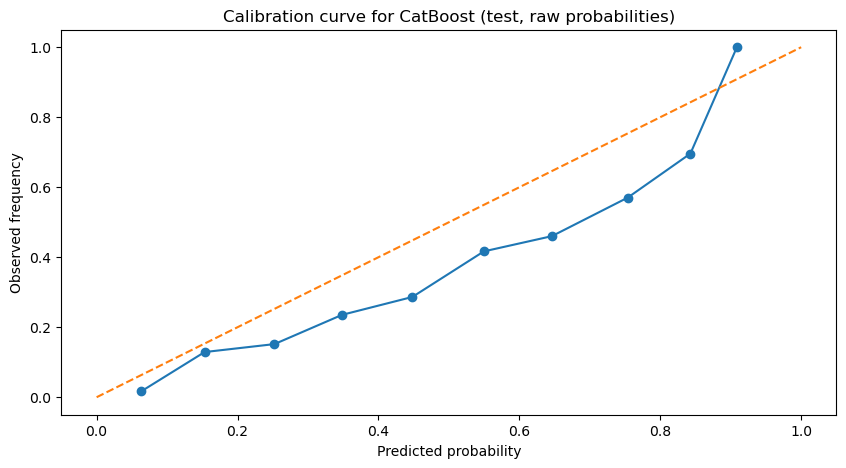

Brier score на test: 0.196777


In [29]:
prob_true, prob_pred = calibration_curve(y_test, test_proba_final, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"Calibration curve for {final_model_name} (test, raw probabilities)")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.show()

print("Brier score на test:", round(brier_score_loss(y_test, test_proba_final), 6))

### Вывод

Калибровочная кривая показывает, где модель завышает или занижает вероятность пролонгации.

Если после калибровки Brier score снижается, это означает, что вероятности стали ближе к реальной частоте события. Для бизнес-решений это полезно: можно увереннее использовать сами вероятности, а не только класс 0/1.

,version,ROC-AUC,PR-AUC,Brier
0,raw_test_proba,0.748063,0.560156,0.196777
1,calibrated_test_proba,0.746238,0.548126,0.180119


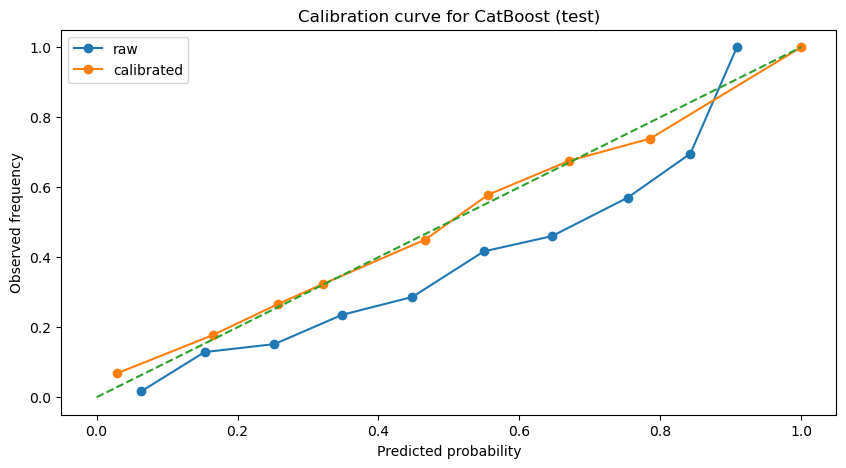

In [30]:
# Пост-калибровка вероятностей на validation -> проверка на test

calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(valid_proba_final, y_valid)

test_proba_calibrated = calibrator.predict(test_proba_final)

calibration_comparison = pd.DataFrame([
    {
        "version": "raw_test_proba",
        "ROC-AUC": roc_auc_score(y_test, test_proba_final),
        "PR-AUC": average_precision_score(y_test, test_proba_final),
        "Brier": brier_score_loss(y_test, test_proba_final),
    },
    {
        "version": "calibrated_test_proba",
        "ROC-AUC": roc_auc_score(y_test, test_proba_calibrated),
        "PR-AUC": average_precision_score(y_test, test_proba_calibrated),
        "Brier": brier_score_loss(y_test, test_proba_calibrated),
    },
])

display(calibration_comparison)

prob_true_raw, prob_pred_raw = calibration_curve(y_test, test_proba_final, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, test_proba_calibrated, n_bins=10)

plt.figure()
plt.plot(prob_pred_raw, prob_true_raw, marker="o", label="raw")
plt.plot(prob_pred_cal, prob_true_cal, marker="o", label="calibrated")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"Calibration curve for {final_model_name} (test)")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.legend()
plt.show()

## Confusion Matrix и classification report на test

In [31]:
test_pred_final = (test_proba_final >= best_threshold).astype(int)
cm = confusion_matrix(y_test, test_pred_final)

display(pd.DataFrame(cm, index=["true_0", "true_1"], columns=["pred_0", "pred_1"]))
print(classification_report(y_test, test_pred_final))

,pred_0,pred_1
true_0,749,296
true_1,164,311


              precision    recall  f1-score   support

           0       0.82      0.72      0.77      1045
           1       0.51      0.65      0.57       475

    accuracy                           0.70      1520
   macro avg       0.67      0.69      0.67      1520
weighted avg       0.72      0.70      0.71      1520



## Feature Importance
Показываем важность признаков для той модели, которая была выбрана финальной.

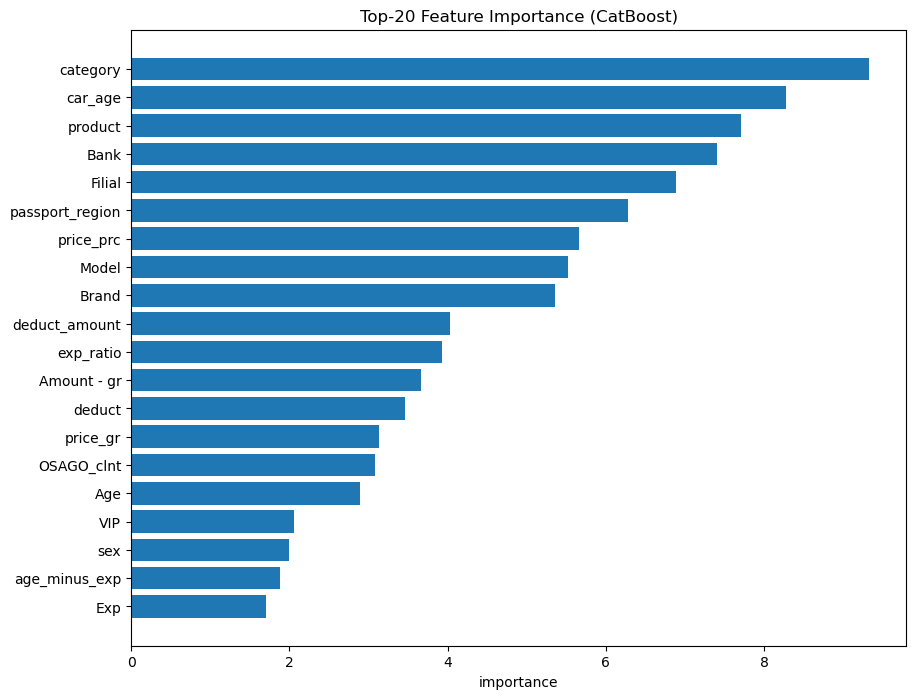

,feature,importance
15,category,9.327039
26,car_age,8.273028
12,product,7.701238
13,Bank,7.404353
0,Filial,6.885848
2,passport_region,6.277396
24,price_prc,5.663750
5,Model,5.523013
4,Brand,5.354002
11,deduct_amount,4.032729


In [32]:
if final_model_name == "CatBoost":
    fi = pd.DataFrame({
        "feature": X_train_cb.columns,
        "importance": final_model.get_feature_importance()
    }).sort_values("importance", ascending=False)
else:
    rf_model = final_model.named_steps["model"]
    feature_names = final_model.named_steps["prep"].get_feature_names_out()
    fi = pd.DataFrame({
        "feature": feature_names,
        "importance": rf_model.feature_importances_
    }).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(fi.head(20)["feature"][::-1], fi.head(20)["importance"][::-1])
plt.title(f"Top-20 Feature Importance ({final_model_name})")
plt.xlabel("importance")
plt.show()

display(fi.head(20))

### Вывод

Анализ важности признаков помог убедиться, что финальная модель опирается на содержательные характеристики клиента, автомобиля, продукта и страховой истории.

## SHAP-анализ
Для интерпретации финальной модели используется SHAP-анализ. Он позволяет оценить вклад признаков в предсказание модели и понять, какие факторы сильнее всего влияют на вероятность пролонгации договора.
Такой анализ важен не только с точки зрения качества модели, но и с точки зрения интерпретируемости результата, что особенно важно для банковских и страховых задач.

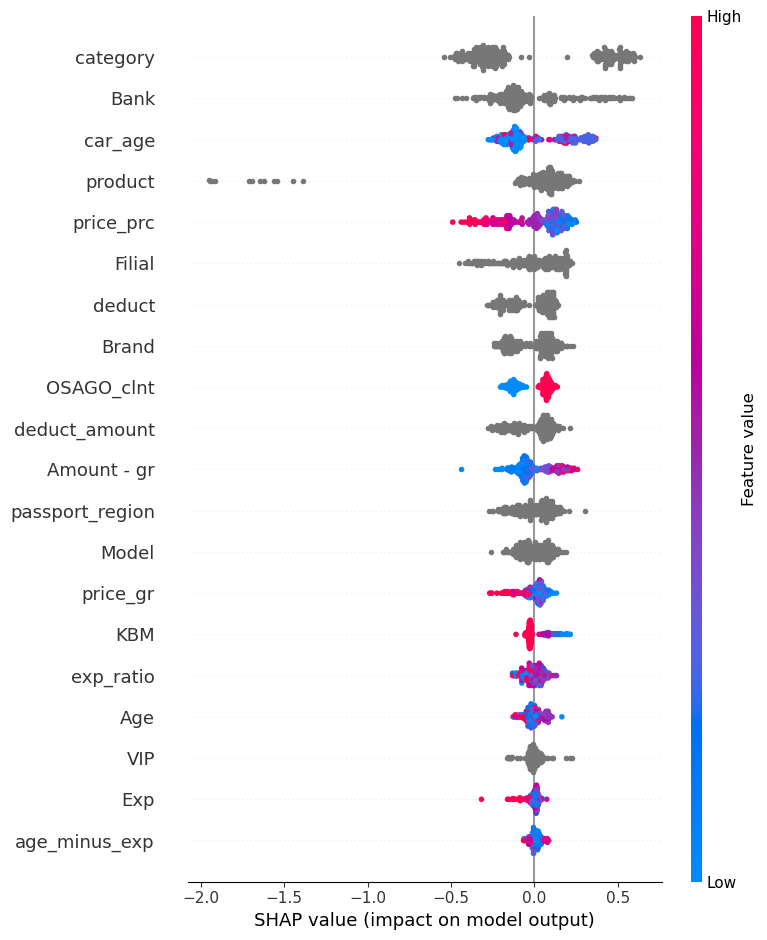

In [33]:
if final_model_name == "CatBoost":
    try:
        import shap

        sample_size = min(300, len(X_test_cb))
        X_shap = X_test_cb.head(sample_size)

        explainer = shap.TreeExplainer(final_model)
        shap_values = explainer.shap_values(X_shap)

        shap.summary_plot(shap_values, X_shap, show=False)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("SHAP skipped:", e)
else:
    print("SHAP skipped: финальная модель не CatBoost.")

SHAP-анализ показывает, что итоговое предсказание модели формируется под влиянием нескольких групп факторов:
- характеристик клиента
- параметров автомобиля
- условий договора
- финансовых признаков

Наибольший вклад в прогноз дают признаки, связанные со стоимостью договора, историей страхования, опытом клиента и параметрами страхового продукта.

Это согласуется с бизнес-логикой задачи: решение о пролонгации зависит не от одного фактора, а от сочетания клиентских, тарифных и продуктовых характеристик.

## Переобучение финальной модели на всей размеченной части

После честной оценки на test переобучаем финальную модель на всей размеченной части.

Для вероятностей делаем отдельный внутренний split:
- одна часть идёт на обучение финальной модели
- небольшая часть — на калибровку вероятностей

In [34]:
full_fe = add_features(train_df.copy())
full_score_fe = add_features(score_df.copy())

for frame in [full_fe, full_score_fe]:
    if "Yr_production" in frame.columns:
        del frame["Yr_production"]
for frame in [full_fe, full_score_fe]:
    if "KBM_prol_est" in frame.columns:
        del frame["KBM_prol_est"]
X_full = full_fe.drop(columns=drop_cols, errors="ignore")
y_full = full_fe["target"].astype(int)
X_score_final = full_score_fe.drop(columns=drop_cols, errors="ignore")

In [35]:
X_full_cb = X_full.drop(columns=["ID"], errors="ignore").copy()
X_score_cb_final = X_score_final.drop(columns=["ID"], errors="ignore").copy()

cat_cols_full = X_full_cb.select_dtypes(include="object").columns.tolist()

for col in cat_cols_full:
    X_full_cb[col] = X_full_cb[col].fillna("MISSING").astype(str)
    X_score_cb_final[col] = X_score_cb_final[col].fillna("MISSING").astype(str)

X_fit_cb, X_calib_cb, y_fit_cb, y_calib_cb = train_test_split(
    X_full_cb,
    y_full,
    test_size=0.15,
    stratify=y_full,
    random_state=RANDOM_STATE
)

final_refit_model = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=RANDOM_STATE,
    verbose=False
)

final_refit_model.fit(
    X_fit_cb,
    y_fit_cb,
    cat_features=cat_cols_full,
    eval_set=(X_calib_cb, y_calib_cb),
    use_best_model=True
)

# вероятности на калибровочной выборке и на score
calib_proba = final_refit_model.predict_proba(X_calib_cb)[:, 1]
score_proba_raw = final_refit_model.predict_proba(X_score_cb_final)[:, 1]

# калибровка вероятностей
final_calibrator = IsotonicRegression(out_of_bounds="clip")
final_calibrator.fit(calib_proba, y_calib_cb)

# откалиброванные вероятности и финальный класс
score_proba = final_calibrator.predict(score_proba_raw)
score_pred = (score_proba >= best_threshold).astype(int)

submission = pd.DataFrame({
    "ID": score_df["ID"].values,
    "target_proba": score_proba,
    "target_pred": score_pred
})

submission.head()

,ID,target_proba,target_pred
0,7599,0.025641,0
1,7600,0.696970,1
2,7601,0.331126,0
3,7602,0.275676,0
4,7603,0.275676,0


In [36]:
submission.to_csv("-1_target_predictions.csv", index=False)
print("Файл сохранён: -1_target_predictions.csv")
print("Итоговая модель:", final_model_name)
print("Итоговый threshold:", round(best_threshold, 4))

Файл сохранён: -1_target_predictions.csv
Итоговая модель: CatBoost
Итоговый threshold: 0.505


## Итоговый вывод

В рамках проекта были:
- проведены аудит данных и EDA
- добавлены интерпретируемые признаки
- удалены дублируемые признаки
- выполнен анализ корреляций и кандидатов на удаление
- обучены и сравнены baseline-модели
- выполнен подбор параметров Random Forest
- обучен CatBoost с early stopping
- финальная модель выбрана **по validation**
- порог выбран **по validation**, а не зафиксирован на 0.5
- итоговая модель честно проверена на test
- отдельно проведена **диагностика калибровки** вероятностей через calibration curve и Brier score
- для финального скоринга добавлена **post-hoc calibration** вероятностей
- финальная версия модели переобучена на всей размеченной части и использована для предсказания `target = -1`

## Важно: интерпретация выбора

Выбор модели в данной задаче зависит не только от значений метрик, но и от предполагаемого сценария её использования.

В рамках проведённого анализа были рассмотрены модели с различными свойствами, что позволяет оценить возможные компромиссы:

- при необходимости высокой интерпретируемости может быть предпочтительна **Logistic Regression**, так как её коэффициенты напрямую отражают влияние признаков и могут быть легко объяснены;

- при акценте на простоту, устойчивость и менее чувствительную к настройкам модель разумным выбором может быть **Random Forest**, который показывает стабильное качество без сложной подготовки данных;

- при приоритете качества, способности улавливать сложные зависимости и более точных вероятностных оценок предпочтение отдаётся **CatBoost**, который показал наилучшие результаты по совокупности метрик.

Таким образом, выбор модели определяется не только сравнением численных метрик, но и контекстом задачи, требованиями к интерпретируемости, устойчивости и формату использования результатов.

В рамках данного решения, при отсутствии дополнительных ограничений, в качестве основной выбрана модель CatBoost как обеспечивающая наиболее стабильное качество.